<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/bobrivets_numerical_programming_hw07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 7
## Наївний класифікатор Баєса для фільтрації спаму

У роботі використовується **Email Spam Classification Dataset**, де:

- `1` — spam;
- `0` — not spam (ham).




## 1. Завантаження та розпакування датасету

In [15]:
!wget -O SpamEmailClassificationDataset.zip "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true"
!unzip -o SpamEmailClassificationDataset.zip


--2026-07-15 21:52:20--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2026-07-15 21:52:20--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/SpamEmailClassificationDataset.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip [following]
--2026-07-15 21:52:21--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/refs/heads/main/SpamEmailClassificationDataset.zip
Res

## 2. Імпорт бібліотек

In [16]:
import math
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

sns.set(style="whitegrid")
np.random.seed(42)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. Зчитування та перевірка даних

In [17]:
csv_path = "./SpamEmailClassificationDataset/combined_data.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())
df.info()

print("\nНазви стовпців:", df.columns.tolist())
print("\nПочатковий розподіл класів:")
display(df["label"].value_counts(dropna=False))


Shape: (14861, 2)


,label,text
0,label,text
1,1,ounce feather bowl hummingbird opec moment ala...
2,1,wulvob get your medircations online qnb ikud v...
3,0,computer connection from cnn com wednesday es...
4,1,university degree obtain a prosperous future m...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   14861 non-null  object
 1   text    14861 non-null  object
dtypes: object(2)
memory usage: 232.3+ KB

Назви стовпців: ['label', 'text']

Початковий розподіл класів:


,count
label,
1,7813
0,7047
label,1


## 4. Нормалізація міток

In [18]:
df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "spam": 1,
        "ham": 0,
        "not spam": 0,
        "1": 1,
        "0": 0,
    })
)

df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna(subset=["text", "label"]).copy()
df["label"] = df["label"].astype(int)

print("Розподіл класів після нормалізації:")
display(df["label"].value_counts())


Розподіл класів після нормалізації:


,count
label,
1,7813
0,7047


## 5. Формування збалансованої вибірки

Для пришвидшення експериментів використаємо однакову кількість повідомлень `spam` і `ham`.


In [19]:
samples_per_class = 3000

spam_count = (df["label"] == 1).sum()
ham_count = (df["label"] == 0).sum()

n_samples = min(samples_per_class, spam_count, ham_count)

if n_samples == 0:
    raise ValueError("Не вдалося знайти обидва класи 0 і 1 у колонці label.")

spam_df = df[df["label"] == 1].sample(n=n_samples, random_state=42)
ham_df = df[df["label"] == 0].sample(n=n_samples, random_state=42)

df_balanced = (
    pd.concat([spam_df, ham_df], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Balanced shape:", df_balanced.shape)
display(df_balanced["label"].value_counts())


Balanced shape: (6000, 2)


,count
label,
1,3000
0,3000


## 6. Візуалізація розподілу класів

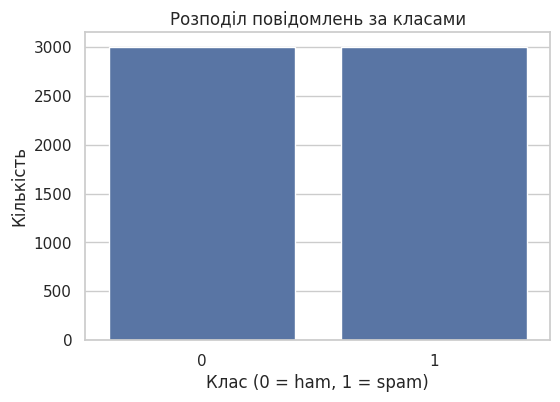

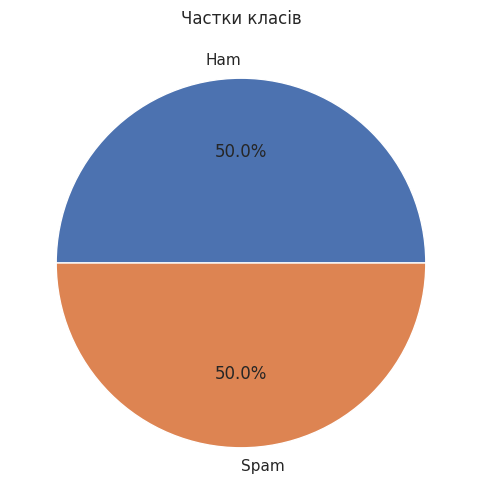

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_balanced, x="label")
plt.title("Розподіл повідомлень за класами")
plt.xlabel("Клас (0 = ham, 1 = spam)")
plt.ylabel("Кількість")
plt.show()

plt.figure(figsize=(6, 6))
df_balanced["label"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Ham", "Spam"]
)
plt.title("Частки класів")
plt.ylabel("")
plt.show()


## 7. Попередня обробка тексту

In [21]:
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", str(text)).lower()
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    words = list(dict.fromkeys(words))
    return " ".join(words)


df_balanced["processed_text"] = df_balanced["text"].apply(preprocess_text)

df_balanced = df_balanced[df_balanced["processed_text"].str.len() > 0].copy()

display(df_balanced[["text", "processed_text", "label"]].head())


,text,processed_text,label
0,deer valley corporation escapenumber escapenum...,deer valley corporation escapenumber target pr...,1
1,rodrick brown wrote use data dumper my h map h...,rodrick brown wrote use data dumper map escape...,0
2,"carrier ,\nvcsc - brand new stock for your att...",carrier vcsc brand new stock attention vocaisc...,1
3,this gem is really movable target sym cdyv pri...,gem really movable target sym cdyv price curre...,1
4,hi there i am trying to install sjava on my wi...,hi trying install sjava window xp machine down...,0


## 8. Поділ на train/test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["processed_text"],
    df_balanced["label"],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["label"],
)

train_spam = X_train[y_train == 1].tolist()
train_ham = X_train[y_train == 0].tolist()

test_spam = X_test[y_test == 1].tolist()
test_ham = X_test[y_test == 0].tolist()

test_emails = {
    i: {"text": text, "label": int(label)}
    for i, (text, label) in enumerate(zip(X_test.tolist(), y_test.tolist()))
}

print("train_spam:", len(train_spam))
print("train_ham:", len(train_ham))
print("test_spam:", len(test_spam))
print("test_ham:", len(test_ham))
print("test_emails:", len(test_emails))


train_spam: 2398
train_ham: 2400
test_spam: 600
test_ham: 600
test_emails: 1200


## 9. Власна реалізація Naive Bayes

In [23]:
class NaiveBayesSpamClassifier:
    def __init__(self, alpha=1.0):
        if alpha <= 0:
            raise ValueError("alpha має бути додатним числом.")

        self.alpha = alpha
        self.spam_word_counts = Counter()
        self.ham_word_counts = Counter()
        self.vocabulary = set()
        self.spam_total_words = 0
        self.ham_total_words = 0
        self.p_spam = 0.5
        self.p_ham = 0.5
        self.is_fitted = False

    def fit(self, train_spam, train_ham):
        if len(train_spam) == 0 or len(train_ham) == 0:
            raise ValueError("Навчальні вибірки train_spam і train_ham не можуть бути порожніми.")

        self.spam_word_counts.clear()
        self.ham_word_counts.clear()
        self.vocabulary.clear()

        for email in train_spam:
            words = str(email).split()
            self.spam_word_counts.update(words)
            self.vocabulary.update(words)

        for email in train_ham:
            words = str(email).split()
            self.ham_word_counts.update(words)
            self.vocabulary.update(words)

        if len(self.vocabulary) == 0:
            raise ValueError("Словник порожній. Перевір preprocessing.")

        self.spam_total_words = sum(self.spam_word_counts.values())
        self.ham_total_words = sum(self.ham_word_counts.values())

        total_emails = len(train_spam) + len(train_ham)
        self.p_spam = len(train_spam) / total_emails
        self.p_ham = len(train_ham) / total_emails
        self.is_fitted = True

        print("Classifier trained successfully")
        print("Vocabulary size:", len(self.vocabulary))

        return self

    def _word_probability(self, word, label):
        if not self.is_fitted:
            raise RuntimeError("Спочатку виконай fit().")

        vocab_size = len(self.vocabulary)

        if label == 1:
            count = self.spam_word_counts.get(word, 0)
            denominator = self.spam_total_words + self.alpha * vocab_size
        elif label == 0:
            count = self.ham_word_counts.get(word, 0)
            denominator = self.ham_total_words + self.alpha * vocab_size
        else:
            raise ValueError("label має бути 0 або 1.")

        return (count + self.alpha) / denominator

    def predict_log_proba(self, text):
        if not self.is_fitted:
            raise RuntimeError("Спочатку виконай fit().")

        words = str(text).split()
        log_spam = math.log(self.p_spam)
        log_ham = math.log(self.p_ham)

        for word in words:
            log_spam += math.log(self._word_probability(word, 1))
            log_ham += math.log(self._word_probability(word, 0))

        return {0: log_ham, 1: log_spam}

    def predict(self, text):
        scores = self.predict_log_proba(text)
        return 1 if scores[1] > scores[0] else 0


classifier = NaiveBayesSpamClassifier(alpha=1.0)
classifier.fit(train_spam, train_ham)


Classifier trained successfully
Vocabulary size: 54728


## 10. Оцінка якості класифікатора

In [24]:
y_true = []
y_pred = []

for item in test_emails.values():
    y_true.append(item["label"])
    y_pred.append(classifier.predict(item["text"]))

if len(y_true) == 0:
    raise ValueError("Тестова вибірка порожня.")

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "value": [accuracy, precision, recall, f1]
})

display(metrics_df)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)


,metric,value
0,Accuracy,0.945000
1,Precision,0.990809
2,Recall,0.898333
3,F1-score,0.942308


              precision    recall  f1-score   support

         Ham       0.91      0.99      0.95       600
        Spam       0.99      0.90      0.94       600

    accuracy                           0.94      1200
   macro avg       0.95      0.95      0.94      1200
weighted avg       0.95      0.94      0.94      1200



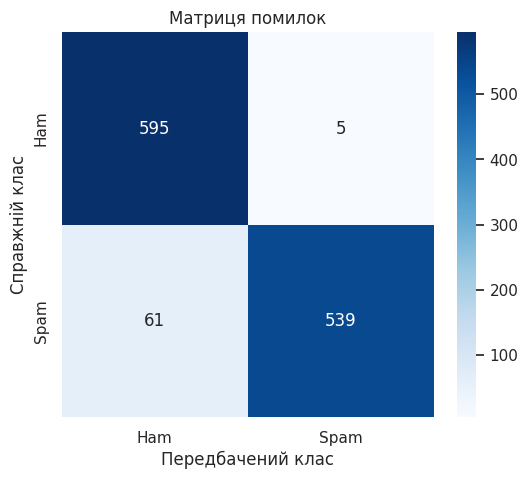

In [25]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)
plt.title("Матриця помилок")
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.show()


## 11. Приклади класифікації

In [26]:
examples = [
    "Congratulations! You have won a free prize. Click here to claim your money.",
    "Hi, can we move our meeting to tomorrow afternoon?",
    "Limited offer! Buy now and receive a huge discount.",
    "Please review the attached report before our call."
]

for message in examples:
    processed = preprocess_text(message)
    prediction = classifier.predict(processed)

    print("Message:", message)
    print("Prediction:", "SPAM" if prediction == 1 else "HAM")
    print("-" * 80)


Message: Congratulations! You have won a free prize. Click here to claim your money.
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Hi, can we move our meeting to tomorrow afternoon?
Prediction: HAM
--------------------------------------------------------------------------------
Message: Limited offer! Buy now and receive a huge discount.
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Please review the attached report before our call.
Prediction: HAM
--------------------------------------------------------------------------------


## 12. Найхарактерніші слова для спаму

In [27]:
spam_word_scores = []

for word in classifier.vocabulary:
    p_word_spam = classifier._word_probability(word, 1)
    p_word_ham = classifier._word_probability(word, 0)

    score = math.log(p_word_spam / p_word_ham)

    spam_word_scores.append({
        "word": word,
        "spam_count": classifier.spam_word_counts[word],
        "ham_count": classifier.ham_word_counts[word],
        "log_probability_ratio": score
    })

spam_words_df = (
    pd.DataFrame(spam_word_scores)
    .query("spam_count >= 5")
    .sort_values("log_probability_ratio", ascending=False)
    .head(20)
)

display(spam_words_df)


,word,spam_count,ham_count,log_probability_ratio
6740,viagra,128,0,5.073479
30032,cialis,127,0,5.065697
16264,canadianpharmacy,90,0,4.724526
30981,hk,247,2,4.628483
5268,autodesk,78,0,4.583115
37262,autocad,73,0,4.517732
14078,csescapenumber,72,0,4.504126
18216,corel,68,0,4.447773
15426,pharmacy,136,1,4.440501
10952,producttestpanel,57,0,4.274110


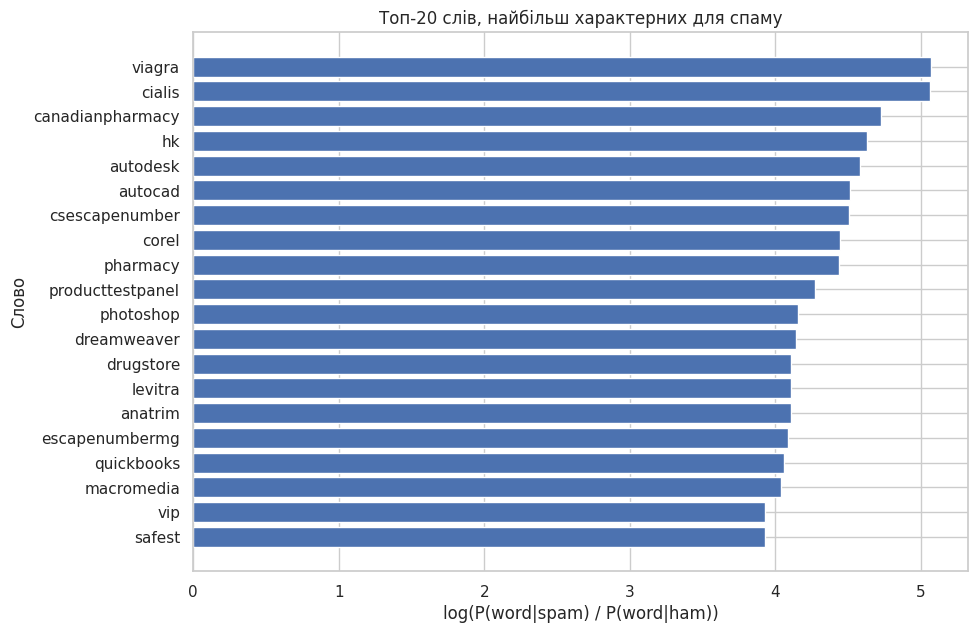

In [28]:
plt.figure(figsize=(10, 7))
plt.barh(
    spam_words_df["word"][::-1],
    spam_words_df["log_probability_ratio"][::-1]
)
plt.title("Топ-20 слів, найбільш характерних для спаму")
plt.xlabel("log(P(word|spam) / P(word|ham))")
plt.ylabel("Слово")
plt.show()


## 13. Висновки

У роботі було завантажено та опрацьовано Email Spam Classification Dataset. Для експерименту сформовано збалансовану вибірку з однаковою кількістю повідомлень класів `spam` і `ham`.

Під час попередньої обробки тексти було приведено до нижнього регістру, очищено від цифр і розділових знаків, видалено стоп-слова, виконано лематизацію та усунуто повторення слів у межах кожного повідомлення.

Для класифікації реалізовано власний мультиноміальний наївний класифікатор Баєса з лапласівським згладжуванням. Якість моделі оцінено за допомогою accuracy, precision, recall, F1-score та матриці помилок.

Аналіз найхарактерніших слів дозволяє визначити терміни, які значно частіше трапляються у спам-повідомленнях, ніж у звичайному листуванні. Наївний Баєс є простим, швидким та інтерпретованим методом для задач класифікації текстів.

Обмеження моделі полягає у припущенні про умовну незалежність слів. Для подальшого покращення можна використати біграми, TF-IDF або сучасні NLP-моделі.
